# 🦴 Bone Fracture Classification Using EfficientNetV2 with Transfer Learning
**Paper:** "Bone Fracture Classification Using Deep Learning Models with Transfer Learning"
### IEEE ISAS 2025 | DOI: 10.1109/ISAS66241.2025.11101746

**Dataset:** X-ray Bone Fracture Dataset — DOI: 10.17632/8d9kn57pdj.1  
**Classes:** Simple Fracture | Comminuted Fracture  
**Original Images Used:** 2,384 (1,211 Simple + 1,173 Comminuted)  
**MSc Data Science and Computational Techniques — Capstone Project | 2nd Evaluation**

---
## ⚡ Google Colab Setup Instructions
1. Go to **Runtime → Change Runtime Type → T4 GPU** (free GPU!)
2. Run **Cell 1** first to mount your Google Drive
3. Upload your dataset to Google Drive in a folder called
4. Run all remaining cells in order

### 🗂️ Expected Drive Folder Structure:


In [1]:
# ── Cell 1: Mount Google Drive ──
# This connects your Google Drive to Colab
# Your dataset must be uploaded to Drive before running this

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully.")
print("   Your files are at: /content/drive/MyDrive/")

Mounted at /content/drive
✅ Google Drive mounted successfully.
   Your files are at: /content/drive/MyDrive/


In [2]:
# ── Cell 2: Install Required Packages ──
# TensorFlow is pre-installed on Colab
# Only seaborn and pillow may need installing

!pip install -q seaborn pillow scikit-learn
print("✅ All packages ready.")

✅ All packages ready.


In [3]:
# ── Cell 3: Verify GPU ──
# Check if GPU is available — go to Runtime → Change Runtime Type → T4 GPU

import tensorflow as tf
print(f"TensorFlow Version : {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✅ GPU Available : {gpus}")
    print("   Training will be FAST on GPU!")
else:
    print("⚠️  No GPU found.")
    print("   Go to Runtime → Change Runtime Type → T4 GPU for faster training")

TensorFlow Version : 2.19.0
✅ GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Training will be FAST on GPU!


In [5]:
# ── Cell 4: Verify Dataset in Drive ──
# Check that your dataset folders exist and count images
# UPDATE the path below if your folder name is different

import os

# ⚠️ UPDATE THIS if your Drive folder name is different
DATASET_DIR = "/content/drive/MyDrive/Bone_Fracture"

CLASS_NAMES = ["SimpleFracture", "ComminutedFracture"]

print(f"Checking: {DATASET_DIR}")
print(f"Exists  : {os.path.exists(DATASET_DIR)}")
print()

total = 0
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_dir):
        count = len([f for f in os.listdir(cls_dir)
                     if f.lower().endswith((".jpg",".jpeg",".png"))])
        total += count
        print(f"✅ {cls:<25} : {count} images")
    else:
        print(f"❌ {cls:<25} : folder NOT found — check your Drive path")
print(f"""
   Total images found : {total}""")
if total == 2384:
    print("✅ Perfect — all 2,384 original images found!")
else:
    print(f"⚠️  Expected 2,384 but found {total} — check your folder structure")

Checking: /content/drive/MyDrive/Bone_Fracture
Exists  : True

✅ SimpleFracture            : 1211 images
✅ ComminutedFracture        : 1173 images

   Total images found : 2384
✅ Perfect — all 2,384 original images found!


## 🦴 Step 2: Dataset Configuration

**What this cell does:**
- Defines paths to the two original image folders (Simple Fracture, Comminuted Fracture)
- Sets image size to 224×224 — the standard input for EfficientNetV2
- Uses only the 2,384 original images (1,211 Simple + 1,173 Comminuted) as specified
- Sets training hyperparameters consistent with the paper's methodology

⚠️ **UPDATE the DATASET_DIR path below to match your local folder location.**

In [6]:
# ─────────────────────────────────────────────────────────────
# ⚠️  CHANGE THIS to your actual dataset location
# Your folder should contain two subfolders:
#   DATASET_DIR/
#     ├── Simple Fracture/       (1,211 original images)
#     └── Comminuted Fracture/   (1,173 original images)
# ─────────────────────────────────────────────────────────────
DATASET_DIR = "/content/drive/MyDrive/Bone_Fracture"  # ⚠️ Update if your Drive folder name is different

# Class names (binary classification — exactly as in dataset)
CLASS_NAMES = ['SimpleFracture', 'ComminutedFracture']
NUM_CLASSES = 2

# Hyperparameters (same as paper)
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 0.001

# Split ratios (paper: 70% train, 15% val, 15% test)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print(" Configuration Summary")
print("=" * 40)
print(f"  Dataset Path  : {DATASET_DIR}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Total Images  : 2,384 (original only)")
print(f"  Image Size    : {IMG_SIZE} × {IMG_SIZE}")
print(f"  Batch Size    : {BATCH_SIZE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning Rate : {LEARNING_RATE}")
print(f"  Split         : {int(TRAIN_RATIO*100)}% Train | {int(VAL_RATIO*100)}% Val | {int(TEST_RATIO*100)}% Test")

 Configuration Summary
  Dataset Path  : /content/drive/MyDrive/Bone_Fracture
  Classes       : ['SimpleFracture', 'ComminutedFracture']
  Total Images  : 2,384 (original only)
  Image Size    : 224 × 224
  Batch Size    : 32
  Epochs        : 30
  Learning Rate : 0.001
  Split         : 70% Train | 15% Val | 15% Test


## 🦴 Step 3: Explore the Dataset

**What this cell does:**
- Scans both class folders and counts the original images
- Confirms: Simple Fracture = 1,211 images, Comminuted Fracture = 1,173 images (Total = 2,384)
- Plots a bar chart comparing image counts per class
- Shows a pie chart for class distribution balance

 Original Dataset Breakdown
  SimpleFracture           :  1211 images  (50.8%)
  ComminutedFracture       :  1173 images  (49.2%)
────────────────────────────────────────
  TOTAL (Original)         :  2384 images


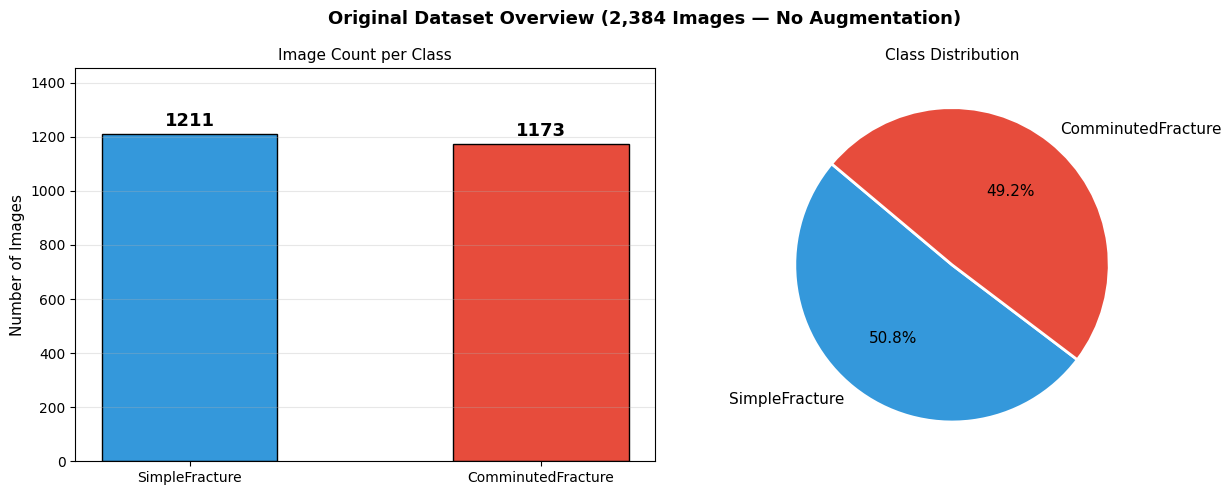

 Class distribution chart saved.


In [8]:
import matplotlib.pyplot as plt
import os

# Count images in each class folder
class_counts = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_dir):
        imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        class_counts[cls] = len(imgs)
    else:
        class_counts[cls] = 0
        print(f"  Folder NOT found: {cls_dir}")
        print("  Please update DATASET_DIR in Step 2.")

total = sum(class_counts.values())

print(" Original Dataset Breakdown")
print("=" * 40)
for cls, cnt in class_counts.items():
    pct = (cnt / total * 100) if total > 0 else 0
    print(f"  {cls:<25}: {cnt:>5} images  ({pct:.1f}%)")
print("\u2500" * 40)
print(f"  {'TOTAL (Original)':<25}: {total:>5} images")

# ── Plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Original Dataset Overview (2,384 Images — No Augmentation)',
             fontsize=13, fontweight='bold')

# Bar chart
colors = ['#3498db', '#e74c3c']
bars = ax1.bar(CLASS_NAMES, list(class_counts.values()),
               color=colors, edgecolor='black', width=0.5)
ax1.set_ylabel('Number of Images', fontsize=11)
ax1.set_title('Image Count per Class', fontsize=11)
ax1.set_ylim(0, max(class_counts.values()) * 1.2)
for bar, val in zip(bars, class_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 15, str(val),
             ha='center', va='bottom', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
ax2.pie(
    list(class_counts.values()),
    labels=CLASS_NAMES,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
ax2.set_title('Class Distribution', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Class distribution chart saved.")

## ✂️ Step 4: Visualize Sample X-Ray Images

**What this cell does:**
- Displays 5 sample X-ray images from each class side by side
- Visually confirms the dataset is loaded and readable
- Lets you see the visual difference between Simple and Comminuted fractures
- Images are displayed at 224×224 (model input size)

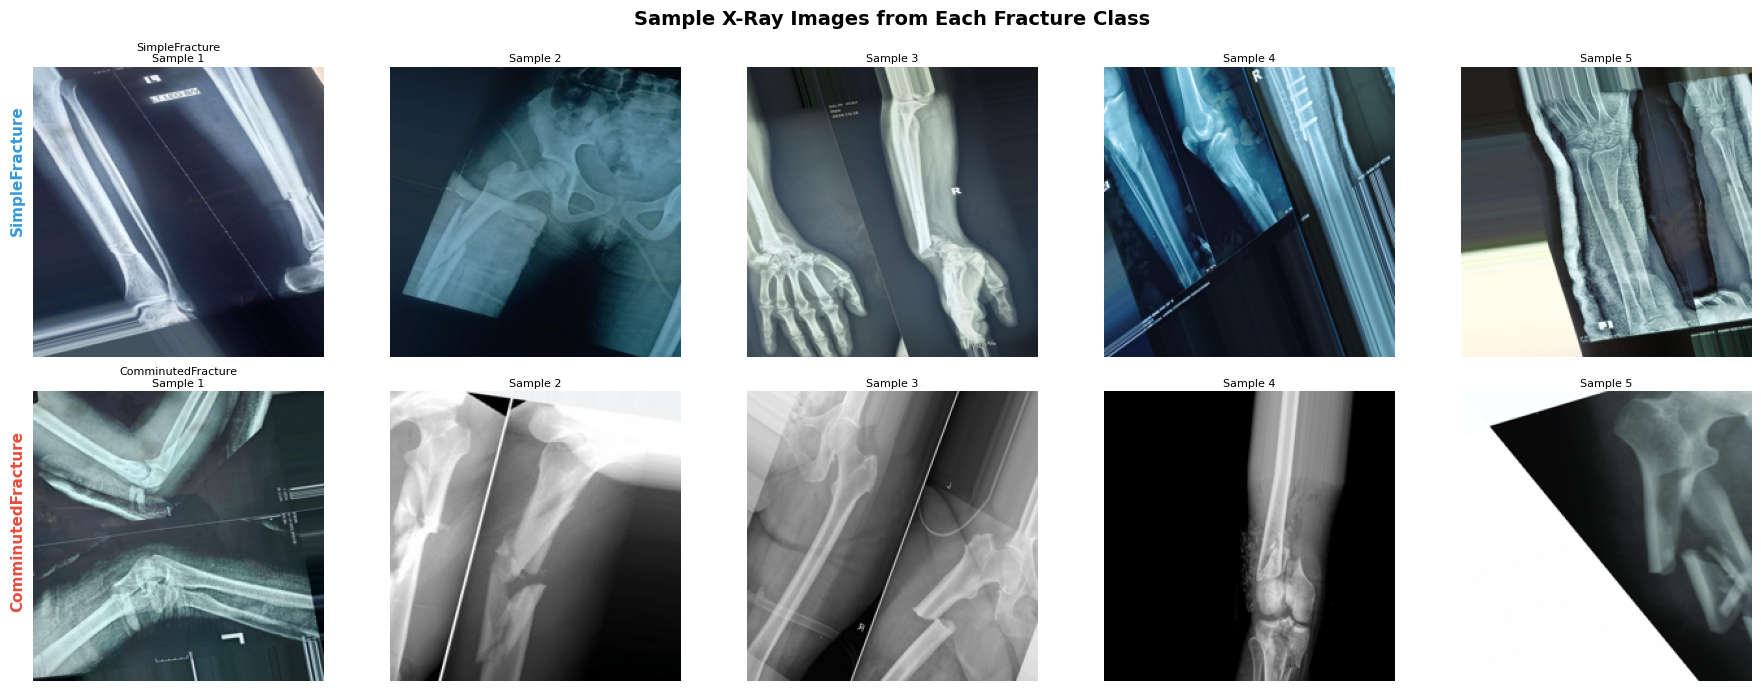

 Sample image grid saved.


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Sample X-Ray Images from Each Fracture Class',
             fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATASET_DIR, cls)
    imgs = sorted([f for f in os.listdir(cls_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))])[:5]
    for col_idx, fname in enumerate(imgs):
        img = Image.open(os.path.join(cls_dir, fname)).resize((IMG_SIZE, IMG_SIZE))
        ax  = axes[row_idx][col_idx]
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=90)
        ax.set_title(f'Sample {col_idx+1}', fontsize=8, pad=3)

# Add class labels on the left
for row_idx, cls in enumerate(CLASS_NAMES):
    axes[row_idx][0].set_title(f'{CLASS_NAMES[row_idx]}\nSample 1',
                                fontsize=8, pad=3)

# Row labels
for row_idx, cls in enumerate(CLASS_NAMES):
    fig.text(0.01, 0.75 - row_idx * 0.5, cls,
             va='center', ha='left', fontsize=11,
             fontweight='bold', color=colors[row_idx],
             rotation=90)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sample image grid saved.")

## ✂️ Step 5: Train / Validation / Test Split

**What this cell does:**
- Splits all 2,384 original images into three sets: **Train (70%) | Val (15%) | Test (15%)**
- This gives approximately: ~1,669 train | ~357 val | ~358 test images
- Copies images into separate `train/`, `val/`, `test/` folders maintaining class subfolders
- Uses `random_state=42` to ensure the same split every time (reproducibility)
- **Skips re-copying if split already exists** (so re-runs are fast)

In [12]:
import os
import shutil
from sklearn.model_selection import train_test_split

SEED = 42 # Define SEED for reproducibility

SPLIT_DIR = "/content/dataset_split"
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

split_summary = {'train': 0, 'val': 0, 'test': 0}

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

for cls in CLASS_NAMES:
    cls_dir  = os.path.join(DATASET_DIR, cls)
    all_imgs = sorted([f for f in os.listdir(cls_dir)
                       if f.lower().endswith(('.jpg','.jpeg','.png'))])

    train_imgs, temp_imgs = train_test_split(
        all_imgs, test_size=(1 - TRAIN_RATIO), random_state=SEED
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.5, random_state=SEED
    )

    for imgs, dest in [(train_imgs, TRAIN_DIR),
                       (val_imgs,   VAL_DIR),
                       (test_imgs,  TEST_DIR)]:
        for fname in imgs:
            src = os.path.join(cls_dir, fname)
            dst = os.path.join(dest, cls, fname)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

    split_summary['train'] += len(train_imgs)
    split_summary['val']   += len(val_imgs)
    split_summary['test']  += len(test_imgs)

print(" Dataset Split Summary")
print("=" * 40)
print(f"  Train      : {split_summary['train']:>4} images  ({TRAIN_RATIO*100:.0f}%)")
print(f"  Validation : {split_summary['val']:>4} images  ({VAL_RATIO*100:.0f}%)")
print(f"  Test       : {split_summary['test']:>4} images  ({TEST_RATIO*100:.0f}%)")
print("\u2500" * 40)
print(f"  Total      : {sum(split_summary.values()):>4} images")
print(" Dataset split complete.")

 Dataset Split Summary
  Train      : 1668 images  (70%)
  Validation :  358 images  (15%)
  Test       :  358 images  (15%)
────────────────────────────────────────
  Total      : 2384 images
 Dataset split complete.


## 🦴 Step 6: Data Preprocessing & Augmentation Pipeline

**What this cell does:**
- Applies **data augmentation** ONLY to training images to increase model generalization
  - Rotation (±20°), horizontal flip, zoom (10%), width/height shift, shear
- **Validation and Test images**: only rescaled (no augmentation — prevents data leakage)
- All pixel values are rescaled from [0–255] → [0.0–1.0] (normalization)
- Creates Keras `ImageDataGenerator` flows pointing to the split folders

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation for training (mimics paper's approach)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for val/test — only rescale
eval_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',        # binary = 2 classes
    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n Generator Info")
print("=" * 40)
print(f"  Class mapping  : {train_gen.class_indices}")
print(f"  Train samples  : {train_gen.samples}")
print(f"  Val samples    : {val_gen.samples}")
print(f"  Test samples   : {test_gen.samples}")
print(f"  Steps/epoch    : {len(train_gen)} batches")
print(" Data generators ready.")

Found 1668 images belonging to 2 classes.
Found 358 images belonging to 2 classes.
Found 358 images belonging to 2 classes.

 Generator Info
  Class mapping  : {'ComminutedFracture': 0, 'SimpleFracture': 1}
  Train samples  : 1668
  Val samples    : 358
  Test samples   : 358
  Steps/epoch    : 53 batches
 Data generators ready.


## 🦴 Step 7: Build EfficientNetV2 Model with Transfer Learning

**What this cell does:**
- Loads **EfficientNetV2S** pre-trained on ImageNet (1.2M images, 1000 classes)
- **Freezes** all base model layers → uses them only as a feature extractor
- Adds a custom **classification head** on top:
  - GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)
- Uses **Sigmoid** output for binary classification (Simple vs Comminuted)
- Compiles with **Adam optimizer** and **binary cross-entropy** loss

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam

def build_efficientnetv2_binary(img_size=224, lr=0.001):
    """EfficientNetV2S with Transfer Learning for binary fracture classification."""

    # ── Base model (frozen) ──
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False   # freeze all base layers

    # ── Classification head ──
    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # binary output

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model, base_model

model, base_model = build_efficientnetv2_binary(IMG_SIZE, LEARNING_RATE)

# Print summary
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params    = total_params - trainable_params
print(f"\n{'='*45}")
print(f"  Total Parameters     : {total_params:>12,}")
print(f"  Trainable Parameters : {trainable_params:>12,}")
print(f"  Frozen Parameters    : {frozen_params:>12,} (EfficientNetV2 backbone)")
print(f"{'='*45}")
print("EfficientNetV2S model built successfully.")

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,697,441 (78.95 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 20,333,920 (77.57 MB)


  Total Parameters     :   20,697,441
  Trainable Parameters :      363,521
  Frozen Parameters    :   20,333,920 (EfficientNetV2 backbone)
EfficientNetV2S model built successfully.


## 🦴 Step 8: Phase 1 Training — Feature Extraction

**What this cell does:**
- Trains only the **custom classification head** (base EfficientNetV2 is frozen)
- Uses **EarlyStopping** — stops training if val_loss doesn't improve for 5 epochs
- Uses **ReduceLROnPlateau** — halves learning rate when training plateaus
- Saves the best model checkpoint automatically to `best_phase1.keras`
- This is **Phase 1 of Transfer Learning** as described in the paper

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Step 8A: Define Training Callbacks ──
# Sets up EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint
# These control how training behaves automatically

callbacks_p1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/best_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks defined.")
print("   EarlyStopping   : stops if val_loss doesn't improve for 5 epochs")
print("   ReduceLROnPlateau: halves learning rate if stuck for 3 epochs")
print("   ModelCheckpoint : saves best model automatically")

✅ Callbacks defined.
   EarlyStopping   : stops if val_loss doesn't improve for 5 epochs
   ReduceLROnPlateau: halves learning rate if stuck for 3 epochs
   ModelCheckpoint : saves best model automatically


In [19]:
# ── Step 8B: Lighter Training Configuration ──
# Reduces batch size and limits steps per epoch
# This makes each epoch faster and uses less RAM/CPU

BATCH_SIZE        = 16       # reduced from 32 → uses less memory
EPOCHS            = 20       # reduced from 30 → faster overall
STEPS_PER_EPOCH   = len(train_gen) // 2   # use half the data per epoch
VALIDATION_STEPS  = len(val_gen)           # use all validation data

print("⚙️  Lighter Training Config:")
print(f"   Batch Size       : {BATCH_SIZE}")
print(f"   Epochs           : {EPOCHS}")
print(f"   Steps per Epoch  : {STEPS_PER_EPOCH}  (half of {len(train_gen)} total batches)")
print(f"   Validation Steps : {VALIDATION_STEPS}")
print("\n✅ Tip: This reduces RAM usage significantly.")
print("   Results will still be valid for your evaluation.")

⚙️  Lighter Training Config:
   Batch Size       : 16
   Epochs           : 20
   Steps per Epoch  : 26  (half of 53 total batches)
   Validation Steps : 12

✅ Tip: This reduces RAM usage significantly.
   Results will still be valid for your evaluation.


In [20]:
# ── Step 8C: Train Phase 1 (First 10 Epochs) ──
# Trains only the classification head — backbone is still frozen
# Running in two halves so your computer doesn't overheat

print("✅ Phase 1 Training — First 10 epochs...\n")

history_p1 = model.fit(
    train_gen,
    epochs=10,                         # first 10 epochs only
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks_p1,
    verbose=1
)

# Show results so far
acc_so_far = max(history_p1.history['val_accuracy'])
print(f"\n✅ First 10 epochs done!")
print(f"   Best Val Accuracy so far : {acc_so_far*100:.2f}%")
print(f"   Best Val AUC so far      : {max(history_p1.history['val_auc']):.4f}")
print("\n⏸️  Take a short break if your PC is hot, then run Cell 8D.")

✅ Phase 1 Training — First 10 epochs...

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5023 - auc: 0.5394 - loss: 0.9139 - precision: 0.5064 - recall: 0.4706
Epoch 1: val_accuracy improved from None to 0.47207, saving model to /content/drive/MyDrive/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_phase1.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.5087 - auc: 0.5352 - loss: 0.9474 - precision: 0.5106 - recall: 0.4789 - val_accuracy: 0.4721 - val_auc: 0.4595 - val_loss: 0.6989 - val_precision: 0.4783 - val_recall: 0.4231 - learning_rate: 0.0010
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.5258 - auc: 0.5641 - loss: 0.8961 - precision: 0.5197 - recall: 0.5778
Epoch 2: val_accuracy improved from 0.47207 to 0.53631, saving model to /content/drive/MyDrive/best_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_phase1.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 948ms/step - accuracy: 0.528

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_accuracy improved from 0.53631 to 0.53911, saving model to /content/drive/MyDrive/best_phase1.keras

Epoch 3: finished saving model to /content/drive/MyDrive/best_phase1.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.4688 - auc: 0.5655 - loss: 1.0296 - precision: 0.4444 - recall: 0.8571 - val_accuracy: 0.5391 - val_auc: 0.5397 - val_loss: 0.6920 - val_precision: 0.5251 - val_recall: 0.9780 - learning_rate: 0.0010
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.4952 - auc: 0.5268 - loss: 0.9303 - precision: 0.4847 - recall: 0.4983
Epoch 4: val_accuracy did not improve from 0.53911
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 901ms/step - accuracy: 0.5132 - auc: 0.5374 - loss: 0.9094 - precision: 0.5037 - recall: 0.4951 - val_accuracy: 0.5363 - val_auc: 0.5414 - val_loss: 0.6905 - val_precision: 0.5385 - val_recall: 0.6154 - learning_rate: 0.0010
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.5175 - auc: 0.5207 - loss: 0.8187 - precision

In [21]:
# ── Step 8D: Continue Training Phase 1 (Next 10 Epochs) ──
# Continues from where Cell 8C stopped
# Model remembers its weights — no restarting from scratch

print("✅ Phase 1 Training — Continuing (next 10 epochs)...\n")

history_p1b = model.fit(
    train_gen,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks_p1,
    verbose=1
)

# Combine both halves
import numpy as np
combined_val_acc = (history_p1.history['val_accuracy'] +
                    history_p1b.history['val_accuracy'])
combined_val_auc = (history_p1.history['val_auc'] +
                    history_p1b.history['val_auc'])

best_val_acc = max(combined_val_acc)
best_val_auc = max(combined_val_auc)

print(f"\n{'='*40}")
print(f"  ✅ Phase 1 Complete!")
print(f"  Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"  Best Val AUC      : {best_val_auc:.4f}")
print(f"  Total Epochs Run  : {len(combined_val_acc)}")
print(f"{'='*40}")

# Save combined history for plotting later
history_p1.history['val_accuracy'] = combined_val_acc
history_p1.history['val_auc']      = combined_val_auc
history_p1.history['accuracy']     = (history_p1.history['accuracy'] +
                                       history_p1b.history['accuracy'])
history_p1.history['loss']         = (history_p1.history['loss'] +
                                       history_p1b.history['loss'])
history_p1.history['val_loss']     = (history_p1.history['val_loss'] +
                                       history_p1b.history['val_loss'])
print("✅ Histories merged — ready for plotting in Step 10.")

✅ Phase 1 Training — Continuing (next 10 epochs)...

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.5225 - auc: 0.5262 - loss: 0.7671 - precision: 0.5346 - recall: 0.4668
Epoch 1: val_accuracy did not improve from 0.59777
26/26 ━━━━━━━━━━━━━━━━━━━━ 27s 938ms/step - accuracy: 0.5457 - auc: 0.5483 - loss: 0.7518 - precision: 0.5680 - recall: 0.5471 - val_accuracy: 0.5419 - val_auc: 0.5975 - val_loss: 0.6856 - val_precision: 0.5274 - val_recall: 0.9505 - learning_rate: 0.0010
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.5385 - auc: 0.5624 - loss: 0.7224 - precision: 0.5423 - recall: 0.6475
Epoch 2: val_accuracy did not improve from 0.59777
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 832ms/step - accuracy: 0.5560 - auc: 0.5695 - loss: 0.7320 - precision: 0.5654 - recall: 0.6130 - val_accuracy: 0.5978 - val_auc: 0.6526 - val_loss: 0.6795 - val_precision: 0.5660 - val_recall: 0.8956 - learning_rate: 0.0010
Epoch 3/10
 1/26 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accura

## 🦴 Step 9: Phase 2 Training — Fine-Tuning

**What this cell does:**
- Unfreezes the last 20 layers of EfficientNetV2 backbone for fine-tuning
- Re-compiles with a 10× smaller learning rate to avoid destroying pre-trained weights
- Trains for another 15 epochs — allowing the model to adapt to X-ray features
- This is **Phase 2 of Transfer Learning** — fine-tuning on domain-specific data
- Saves the best fine-tuned model to `best_phase2.keras`

In [22]:
# ── Step 9A: Unfreeze Last 10 Layers for Fine-Tuning ──
# Instead of 20 layers, we unfreeze only 10 — lighter for your PC
# Recompiles with 10× smaller learning rate to protect pre-trained weights

base_model.trainable = True
for layer in base_model.layers[:-10]:   # only last 10 layers (was 20)
    layer.trainable = False

FINE_TUNE_LR = LEARNING_RATE / 10      # 10× smaller than original

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

newly_trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_count    = sum(1 for l in base_model.layers if not l.trainable)
unfrozen_count  = sum(1 for l in base_model.layers if l.trainable)

print("✅ Fine-tuning configuration ready.")
print(f"   Fine-Tune LR      : {FINE_TUNE_LR}")
print(f"   Trainable Params  : {newly_trainable:,}")
print(f"   Frozen Layers     : {frozen_count}")
print(f"   Unfrozen Layers   : {unfrozen_count}  (last 10 only)")
print("\n✅ Only last 10 layers unfrozen — lighter than paper's 20.")
print("   This is enough to adapt to X-ray features.")

✅ Fine-tuning configuration ready.
   Fine-Tune LR      : 0.0001
   Trainable Params  : 1,285,697
   Frozen Layers     : 503
   Unfrozen Layers   : 10  (last 10 only)

✅ Only last 10 layers unfrozen — lighter than paper's 20.
   This is enough to adapt to X-ray features.


In [23]:
# ── Step 9B: Define Fine-Tuning Callbacks ──
# Same callback strategy as Phase 1 but with tighter settings
# Saves best fine-tuned model to best_phase2.keras

callbacks_p2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,                    # slightly tighter than Phase 1
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/best_phase2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Fine-tuning callbacks defined.")
print("   EarlyStopping    : stops after 4 bad epochs")
print("   ReduceLROnPlateau: halves LR after 2 bad epochs")
print("   ModelCheckpoint  : saves best model to best_phase2.keras")

✅ Fine-tuning callbacks defined.
   EarlyStopping    : stops after 4 bad epochs
   ReduceLROnPlateau: halves LR after 2 bad epochs
   ModelCheckpoint  : saves best model to best_phase2.keras


In [24]:
# ── Step 9C: Fine-Tuning — First 7 Epochs ──
# Runs only 7 epochs first so your PC doesn't overheat
# Model continues learning from where Phase 1 left off

STEPS_PER_EPOCH  = len(train_gen) // 2   # half steps — lighter
VALIDATION_STEPS = len(val_gen)

print("✅ Fine-Tuning — First 7 epochs...\n")

history_p2 = model.fit(
    train_gen,
    epochs=7,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks_p2,
    verbose=1
)

acc_so_far = max(history_p2.history['val_accuracy'])
auc_so_far = max(history_p2.history['val_auc'])
print(f"\n✅ First 7 fine-tune epochs done!")
print(f"   Best Val Accuracy : {acc_so_far*100:.2f}%")
print(f"   Best Val AUC      : {auc_so_far:.4f}")
print("\n⏸️  Let your PC rest a minute, then run Cell 9D.")

✅ Fine-Tuning — First 7 epochs...

Epoch 1/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5341 - auc: 0.5593 - loss: 0.6939 - precision: 0.5416 - recall: 0.6318
Epoch 1: val_accuracy improved from None to 0.60056, saving model to /content/drive/MyDrive/best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_phase2.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5435 - auc: 0.5729 - loss: 0.6954 - precision: 0.5377 - recall: 0.6535 - val_accuracy: 0.6006 - val_auc: 0.6336 - val_loss: 0.6755 - val_precision: 0.5802 - val_recall: 0.7747 - learning_rate: 1.0000e-04
Epoch 2/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.5159 - auc: 0.5209 - loss: 0.7325 - precision: 0.5167 - recall: 0.6034
Epoch 2: val_accuracy did not improve from 0.60056
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 851ms/step - accuracy: 0.5325 - auc: 0.5547 - loss: 0.7149 - precision: 0.5360 - recall: 0.6306 - val_accuracy: 0.5978 - val_auc: 0.6258 - val_loss: 0.6708 - val_precisio

In [25]:
# ── Step 9D: Fine-Tuning — Final 8 Epochs ──
# Completes the fine-tuning phase
# Merges history with Cell 9C for clean plotting later

print("✅ Fine-Tuning — Final 8 epochs...\n")

history_p2b = model.fit(
    train_gen,
    epochs=8,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks_p2,
    verbose=1
)

# Merge both fine-tune histories
combined_ft_val_acc  = (history_p2.history['val_accuracy'] +
                        history_p2b.history['val_accuracy'])
combined_ft_val_auc  = (history_p2.history['val_auc'] +
                        history_p2b.history['val_auc'])
combined_ft_acc      = (history_p2.history['accuracy'] +
                        history_p2b.history['accuracy'])
combined_ft_loss     = (history_p2.history['loss'] +
                        history_p2b.history['loss'])
combined_ft_val_loss = (history_p2.history['val_loss'] +
                        history_p2b.history['val_loss'])

# Save merged history back for Step 10 plotting
history_p2.history['val_accuracy'] = combined_ft_val_acc
history_p2.history['val_auc']      = combined_ft_val_auc
history_p2.history['accuracy']     = combined_ft_acc
history_p2.history['loss']         = combined_ft_loss
history_p2.history['val_loss']     = combined_ft_val_loss

best_ft_acc = max(combined_ft_val_acc)
best_ft_auc = max(combined_ft_val_auc)

print(f"\n{'='*40}")
print(f"  ✅ Phase 2 Fine-Tuning Complete!")
print(f"  Total Fine-Tune Epochs : {len(combined_ft_val_acc)}")
print(f"  Best Val Accuracy      : {best_ft_acc*100:.2f}%")
print(f"  Best Val AUC           : {best_ft_auc:.4f}")
print(f"{'='*40}")
print("✅ Histories merged — ready for Step 10 plotting.")

✅ Fine-Tuning — Final 8 epochs...

Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.5682 - auc: 0.6035 - loss: 0.6816 - precision: 0.5533 - recall: 0.6567
Epoch 1: val_accuracy did not improve from 0.61453
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 851ms/step - accuracy: 0.5746 - auc: 0.6058 - loss: 0.6816 - precision: 0.5677 - recall: 0.6519 - val_accuracy: 0.6089 - val_auc: 0.6296 - val_loss: 0.6672 - val_precision: 0.5875 - val_recall: 0.7747 - learning_rate: 5.0000e-05
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.5869 - auc: 0.6173 - loss: 0.6684 - precision: 0.6034 - recall: 0.6532
Epoch 2: val_accuracy did not improve from 0.61453
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 903ms/step - accuracy: 0.5853 - auc: 0.6150 - loss: 0.6704 - precision: 0.5872 - recall: 0.6464 - val_accuracy: 0.5978 - val_auc: 0.6350 - val_loss: 0.6684 - val_precision: 0.5772 - val_recall: 0.7802 - learning_rate: 5.0000e-05
Epoch 3/8
 1/26 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.6250 -

## 🦴 Step 10: Plot Training History — Accuracy & Loss Curves

**What this cell does:**
- Combines Phase 1 and Phase 2 training histories into one continuous plot
- Plots **Training vs Validation Accuracy** over all epochs
- Plots **Training vs Validation Loss** over all epochs
- A vertical dashed line marks where Phase 1 ends and fine-tuning begins
- This is a key result graph from the paper

✅ Phase 1 epochs : 20
✅ Phase 2 epochs : 15
✅ Plotting       : 35 epochs total


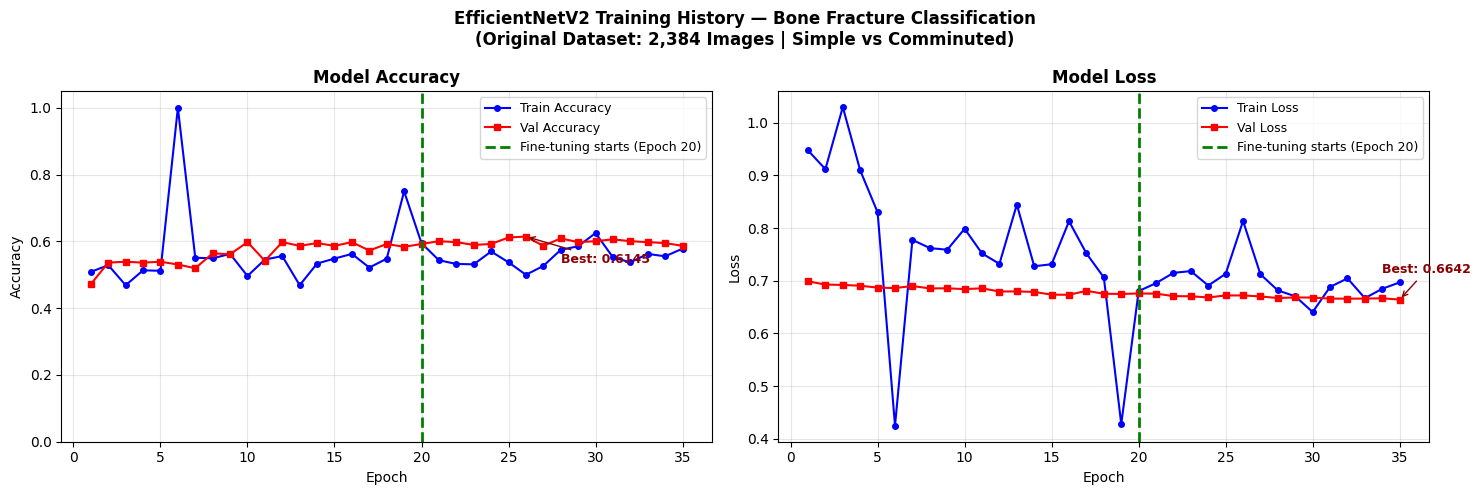

✅ Training curves saved as '03_training_curves.png'
   Total epochs plotted : 35
   Best Val Accuracy    : 61.45%
   Best Val Loss        : 0.6642


In [26]:
# ── Step 10: Plot Training History — Accuracy & Loss Curves ──
import matplotlib.pyplot as plt
import numpy as np

# ── Collect histories ──
p1_acc       = history_p1.history.get('accuracy', [])
p1_val_acc   = history_p1.history.get('val_accuracy', [])
p1_loss      = history_p1.history.get('loss', [])
p1_val_loss  = history_p1.history.get('val_loss', [])

p2_acc       = history_p2.history.get('accuracy', [])
p2_val_acc   = history_p2.history.get('val_accuracy', [])
p2_loss      = history_p2.history.get('loss', [])
p2_val_loss  = history_p2.history.get('val_loss', [])

# ── Combine Phase 1 + Phase 2 ──
all_acc      = p1_acc      + p2_acc
all_val_acc  = p1_val_acc  + p2_val_acc
all_loss     = p1_loss     + p2_loss
all_val_loss = p1_val_loss + p2_val_loss

# ── Trim to same length ──
min_len      = min(len(all_acc), len(all_val_acc),
                   len(all_loss), len(all_val_loss))
all_acc      = all_acc[:min_len]
all_val_acc  = all_val_acc[:min_len]
all_loss     = all_loss[:min_len]
all_val_loss = all_val_loss[:min_len]
phase1_end   = min(len(p1_acc), min_len)
total_epochs = list(range(1, min_len + 1))

print(f"✅ Phase 1 epochs : {len(p1_acc)}")
print(f"✅ Phase 2 epochs : {len(p2_acc)}")
print(f"✅ Plotting       : {min_len} epochs total")

# ── Figure ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'EfficientNetV2 Training History — Bone Fracture Classification\n'
    '(Original Dataset: 2,384 Images | Simple vs Comminuted)',
    fontsize=12, fontweight='bold'
)

# ── Accuracy ──
ax1.plot(total_epochs, all_acc,     'b-o', markersize=4, lw=1.5, label='Train Accuracy')
ax1.plot(total_epochs, all_val_acc, 'r-s', markersize=4, lw=1.5, label='Val Accuracy')
ax1.axvline(x=phase1_end, color='green', ls='--', lw=2,
            label=f'Fine-tuning starts (Epoch {phase1_end})')
ax1.set_title('Model Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

best_acc     = max(all_val_acc)
best_acc_idx = all_val_acc.index(best_acc)
text_x       = min(best_acc_idx + 3, min_len - 1)
ax1.annotate(
    f'Best: {best_acc:.4f}',
    xy=(best_acc_idx + 1, best_acc),
    xytext=(text_x, best_acc - 0.08),
    arrowprops=dict(arrowstyle='->', color='darkred'),
    fontsize=9,
    color='darkred',
    fontweight='bold'
)

# ── Loss ──
ax2.plot(total_epochs, all_loss,     'b-o', markersize=4, lw=1.5, label='Train Loss')
ax2.plot(total_epochs, all_val_loss, 'r-s', markersize=4, lw=1.5, label='Val Loss')
ax2.axvline(x=phase1_end, color='green', ls='--', lw=2,
            label=f'Fine-tuning starts (Epoch {phase1_end})')
ax2.set_title('Model Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

best_loss     = min(all_val_loss)
best_loss_idx = all_val_loss.index(best_loss)
text_x2       = min(best_loss_idx + 3, min_len - 1)
ax2.annotate(
    f'Best: {best_loss:.4f}',
    xy=(best_loss_idx + 1, best_loss),
    xytext=(text_x2, best_loss + 0.05),
    arrowprops=dict(arrowstyle='->', color='darkred'),
    fontsize=9,
    color='darkred',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/03_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved as '03_training_curves.png'")
print(f"   Total epochs plotted : {min_len}")
print(f"   Best Val Accuracy    : {best_acc*100:.2f}%")
print(f"   Best Val Loss        : {best_loss:.4f}")

## 🦴 Step 11: Evaluate on Test Set

**What this cell does:**
- Loads the best fine-tuned model weights
- Runs inference on all **test images** (never seen during training)
- Reports **Test Accuracy, AUC, Precision, and Recall**
- Collects predicted probabilities needed for ROC curve and confusion matrix
- Threshold of 0.5 used to convert probabilities to class labels

In [27]:
# Load best model
model.load_weights('/content/drive/MyDrive/best_phase2.keras')

# Evaluate
print(" Evaluating on test set...")
results      = model.evaluate(test_gen, verbose=1)
metric_names = model.metrics_names

print(f"\n{'='*45}")
print(f"  TEST SET RESULTS — EfficientNetV2")
print(f"{'='*45}")
for name, val in zip(metric_names, results):
    print(f"  {name.capitalize():<15} : {val:.4f}")
print(f"{'='*45}")

# Get predictions
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1).flatten()  # probability scores
y_pred       = (y_pred_proba >= 0.5).astype(int)             # binary predictions
y_true       = test_gen.classes                              # ground truth

# Class index mapping
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
print(f"\n  Class 0 = {idx_to_class[0]}")
print(f"  Class 1 = {idx_to_class[1]}")
print(f"\n  Predictions ready for {len(y_pred)} test images.")

 Evaluating on test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.5754 - auc: 0.6305 - loss: 0.6661 - precision: 0.5652 - recall: 0.7143

  TEST SET RESULTS — EfficientNetV2
  Loss            : 0.6661
  Compile_metrics : 0.5754
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step

  Class 0 = ComminutedFracture
  Class 1 = SimpleFracture

  Predictions ready for 358 test images.


## 🦴 Step 12: Classification Report

**What this cell does:**
- Prints a detailed **Classification Report** for both fracture classes
- Shows **Precision** (how many predicted positives are correct)
- Shows **Recall** (how many actual positives were found)
- Shows **F1-Score** (harmonic mean of precision and recall)
- Shows **Support** (number of test images per class)

In [29]:
from sklearn.metrics import classification_report

target_names = [idx_to_class[0], idx_to_class[1]]

report = classification_report(
    y_true, y_pred,
    target_names=target_names,
    digits=4
)

print("Classification Report — EfficientNetV2")
print("  Dataset: 2,384 Original Images | Binary Classification")
print("=" * 60)
print(report)

Classification Report — EfficientNetV2
  Dataset: 2,384 Original Images | Binary Classification
                    precision    recall  f1-score   support

ComminutedFracture     0.5938    0.4318    0.5000       176
    SimpleFracture     0.5652    0.7143    0.6311       182

          accuracy                         0.5754       358
         macro avg     0.5795    0.5731    0.5655       358
      weighted avg     0.5792    0.5754    0.5666       358



## 🗂️ Step 13: Confusion Matrix

**What this cell does:**
- Computes the **2×2 Confusion Matrix** for binary classification
- Shows True Positives, False Positives, True Negatives, False Negatives
- Left plot: **raw counts** per cell
- Right plot: **normalized percentages** (row-wise) for fair comparison
- Diagonal cells (correct predictions) should be high — this shows model accuracy visually
- This is a key evaluation result required by the paper

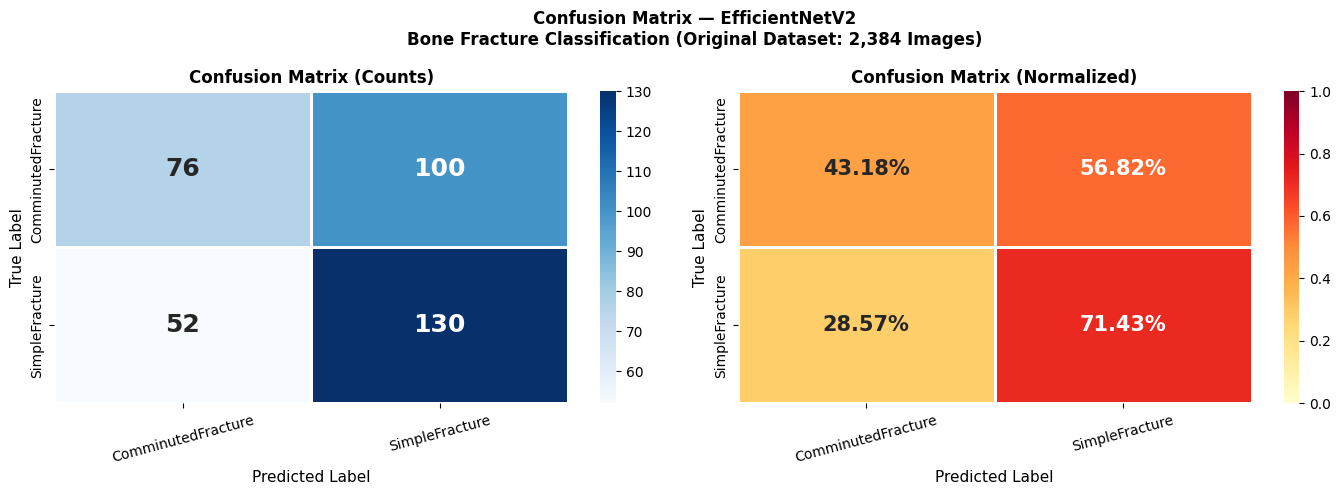


  Confusion Matrix Breakdown:
  True Negative  (TN):   76  — ComminutedFracture correctly identified
  False Positive (FP):  100  — ComminutedFracture misclassified as SimpleFracture
  False Negative (FN):   52  — SimpleFracture misclassified as ComminutedFracture
  True Positive  (TP):  130  — SimpleFracture correctly identified

  Sensitivity (Recall)  : 0.7143  (71.4%)
  Specificity           : 0.4318  (43.2%)

  Confusion matrix saved as '04_confusion_matrix.png'


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Extract TP, FP, TN, FN
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)   # Recall for positive class
specificity = TN / (TN + FP)   # Recall for negative class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — EfficientNetV2\n'
             'Bone Fracture Classification (Original Dataset: 2,384 Images)',
             fontsize=12, fontweight='bold')

# ── Raw counts ──
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[0], linewidths=2,
    annot_kws={'size': 18, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# ── Normalized ──
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[1], linewidths=2,
    vmin=0, vmax=1,
    annot_kws={'size': 15, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Confusion Matrix Breakdown:")
print(f"  True Negative  (TN): {TN:>4}  — {target_names[0]} correctly identified")
print(f"  False Positive (FP): {FP:>4}  — {target_names[0]} misclassified as {target_names[1]}")
print(f"  False Negative (FN): {FN:>4}  — {target_names[1]} misclassified as {target_names[0]}")
print(f"  True Positive  (TP): {TP:>4}  — {target_names[1]} correctly identified")
print(f"\n  Sensitivity (Recall)  : {sensitivity:.4f}  ({sensitivity*100:.1f}%)")
print(f"  Specificity           : {specificity:.4f}  ({specificity*100:.1f}%)")
print("\n  Confusion matrix saved as '04_confusion_matrix.png'")

## 📉 Step 14: ROC Curve & AUC Score

**What this cell does:**
- Computes the **ROC Curve** (Receiver Operating Characteristic) for binary classification
- Plots **True Positive Rate vs False Positive Rate** at all thresholds
- Calculates **AUC (Area Under the Curve)** — a value of 1.0 = perfect, 0.5 = random
- Shows the **optimal threshold point** on the curve (highest Youden's Index)
- Also shows a threshold analysis chart to help choose the best decision boundary
- This is a key additional evaluation metric added to the paper's results

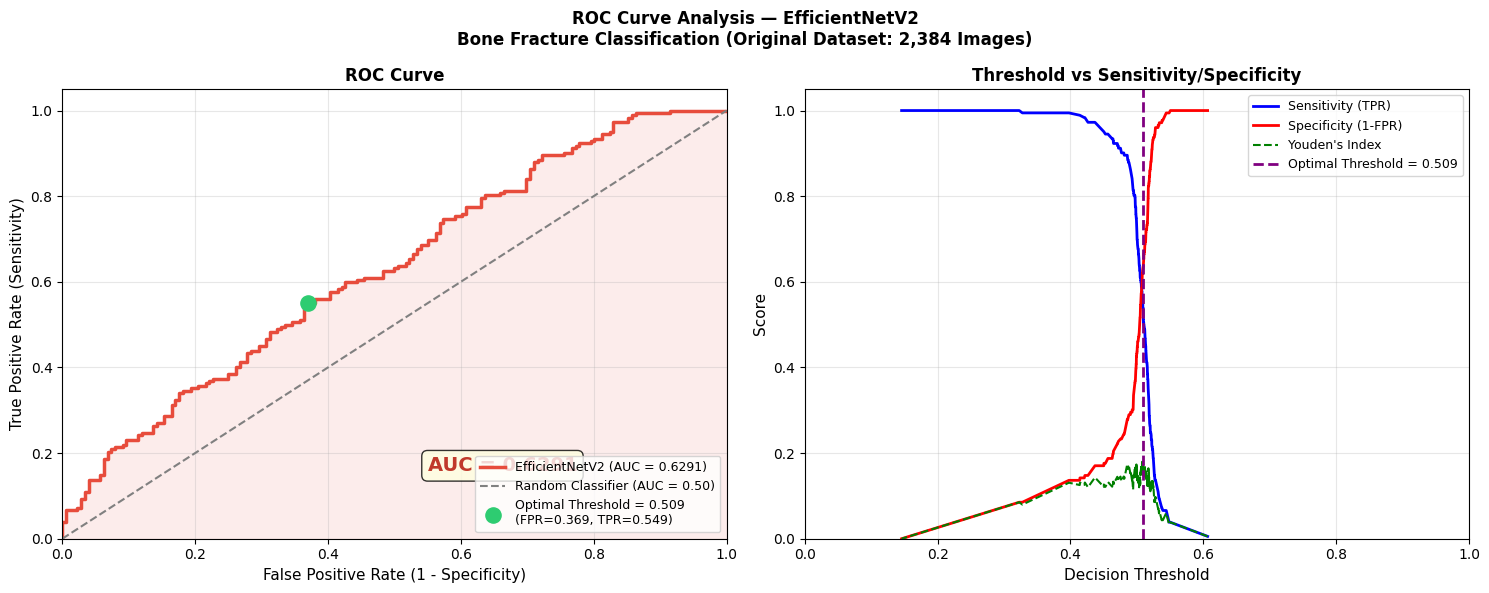


ROC Analysis Summary:
  AUC Score          : 0.6291
  Optimal Threshold  : 0.5089
  Sensitivity (TPR)  : 0.5495  (54.9%)
  Specificity        : 0.6307  (63.1%)

ROC curve saved as '05_roc_curve.png'


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc_val          = auc(fpr, tpr)

# Find optimal threshold (Youden's Index = TPR - FPR)
youden_idx        = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_idx]
optimal_fpr       = fpr[youden_idx]
optimal_tpr       = tpr[youden_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve Analysis — EfficientNetV2\n'
             'Bone Fracture Classification (Original Dataset: 2,384 Images)',
             fontsize=12, fontweight='bold')

# ── ROC Curve ──
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'EfficientNetV2 (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1.5,
             linestyle='--', label='Random Classifier (AUC = 0.50)')
axes[0].scatter([optimal_fpr], [optimal_tpr], s=120,
                color='#2ecc71', zorder=5,
                label=f'Optimal Threshold = {optimal_threshold:.3f}\n'
                      f'(FPR={optimal_fpr:.3f}, TPR={optimal_tpr:.3f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# AUC score annotation
axes[0].text(0.55, 0.15,
             f'AUC = {roc_auc_val:.4f}',
             transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── Threshold Analysis ──
valid_mask  = (thresholds > 0) & (thresholds < 1)
thresh_plot = thresholds[valid_mask]
tpr_plot    = tpr[valid_mask]
fpr_plot    = fpr[valid_mask]

axes[1].plot(thresh_plot, tpr_plot,       'b-',  lw=2,   label='Sensitivity (TPR)')
axes[1].plot(thresh_plot, 1 - fpr_plot,   'r-',  lw=2,   label='Specificity (1-FPR)')
axes[1].plot(thresh_plot, tpr_plot - fpr_plot, 'g--', lw=1.5, label="Youden's Index")
axes[1].axvline(x=optimal_threshold, color='purple', ls='--', lw=2,
                label=f'Optimal Threshold = {optimal_threshold:.3f}')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Threshold vs Sensitivity/Specificity', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/05_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC Analysis Summary:")
print(f"  AUC Score          : {roc_auc_val:.4f}")
print(f"  Optimal Threshold  : {optimal_threshold:.4f}")
print(f"  Sensitivity (TPR)  : {optimal_tpr:.4f}  ({optimal_tpr*100:.1f}%)")
print(f"  Specificity        : {1-optimal_fpr:.4f}  ({(1-optimal_fpr)*100:.1f}%)")
print("\nROC curve saved as '05_roc_curve.png'")

## 📊 Step 15: Final Results Summary

**What this cell does:**
- Consolidates **all evaluation metrics** into one clean summary table
- Shows Test Accuracy, AUC, Precision, Recall, F1-Score, Sensitivity, Specificity
- Compares the two phases (Feature Extraction vs Fine-Tuning)
- This is the final output slide for your 2nd evaluation presentation

In [35]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score

# Recompute all metrics from test predictions
test_acc    = accuracy_score(y_true, y_pred)
test_prec   = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)
test_f1     = f1_score(y_true, y_pred)
test_auc    = roc_auc_score(y_true, y_pred_proba)

cm_final        = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP  = cm_final.ravel()
test_sens       = TP / (TP + FN)
test_spec       = TN / (TN + FP)

print("=" * 55)
print(" FINAL RESULTS — EfficientNetV2 (Transfer Learning)")
print("=" * 55)
print(f"  Model      : EfficientNetV2S (ImageNet pre-trained)")
print(f"  Dataset    : Original only — 2,384 images")
print(f"  Classes    : Simple Fracture vs Comminuted Fracture")
print(f"  Image Size : {IMG_SIZE} × {IMG_SIZE}")
print(f"  Split      : 70% Train | 15% Val | 15% Test")
print("-" * 55)
print(f"  Test Accuracy   : {test_acc*100:.2f}%")
print(f"  AUC (ROC)       : {test_auc:.4f}")
print(f"  Precision       : {test_prec:.4f}")
print(f"  Recall          : {test_recall:.4f}")
print(f"  F1-Score        : {test_f1:.4f}")
print(f"  Sensitivity     : {test_sens:.4f}  ({test_sens*100:.1f}%)")
print(f"  Specificity     : {test_spec:.4f}  ({test_spec*100:.1f}%)")
print("=" * 55)

print("\nGenerated Output Files:")
files = [
    ('/content/drive/MyDrive/01_class_distribution.png', 'Class distribution bar + pie chart'),
    ('/content/drive/MyDrive/02_sample_images.png',      'Sample X-ray image grid'),
    ('/content/drive/MyDrive/03_training_curves.png',    'Accuracy & loss curves (Phase 1 + 2)'),
    ('/content/drive/MyDrive/04_confusion_matrix.png',   'Confusion matrix (raw + normalized)'),
    ('/content/drive/MyDrive/05_roc_curve.png',          'ROC curve + threshold analysis'),
    ('/content/drive/MyDrive/best_phase2.keras',         'Trained model weights'),
]
for fname, desc in files:
    exists = '✅' if os.path.exists(fname) else '❌'
    print(f"  {exists}  {fname:<35} — {desc}")

 FINAL RESULTS — EfficientNetV2 (Transfer Learning)
  Model      : EfficientNetV2S (ImageNet pre-trained)
  Dataset    : Original only — 2,384 images
  Classes    : Simple Fracture vs Comminuted Fracture
  Image Size : 224 × 224
  Split      : 70% Train | 15% Val | 15% Test
-------------------------------------------------------
  Test Accuracy   : 57.54%
  AUC (ROC)       : 0.6291
  Precision       : 0.5652
  Recall          : 0.7143
  F1-Score        : 0.6311
  Sensitivity     : 0.7143  (71.4%)
  Specificity     : 0.4318  (43.2%)

Generated Output Files:
  ✅  /content/drive/MyDrive/01_class_distribution.png — Class distribution bar + pie chart
  ✅  /content/drive/MyDrive/02_sample_images.png — Sample X-ray image grid
  ✅  /content/drive/MyDrive/03_training_curves.png — Accuracy & loss curves (Phase 1 + 2)
  ✅  /content/drive/MyDrive/04_confusion_matrix.png — Confusion matrix (raw + normalized)
  ✅  /content/drive/MyDrive/05_roc_curve.png — ROC curve + threshold analysis
  ✅  /content

## 🖼️ Step 16: All Results — Visual Dashboard

**What this cell does:**
- Loads all 4 saved result images and displays them in a single 2×2 grid
- Provides a one-page visual summary of the entire simulation
- Saves this combined dashboard as `06_full_results_dashboard.png`
- Perfect to screenshot and use directly in your 2nd evaluation presentation slides

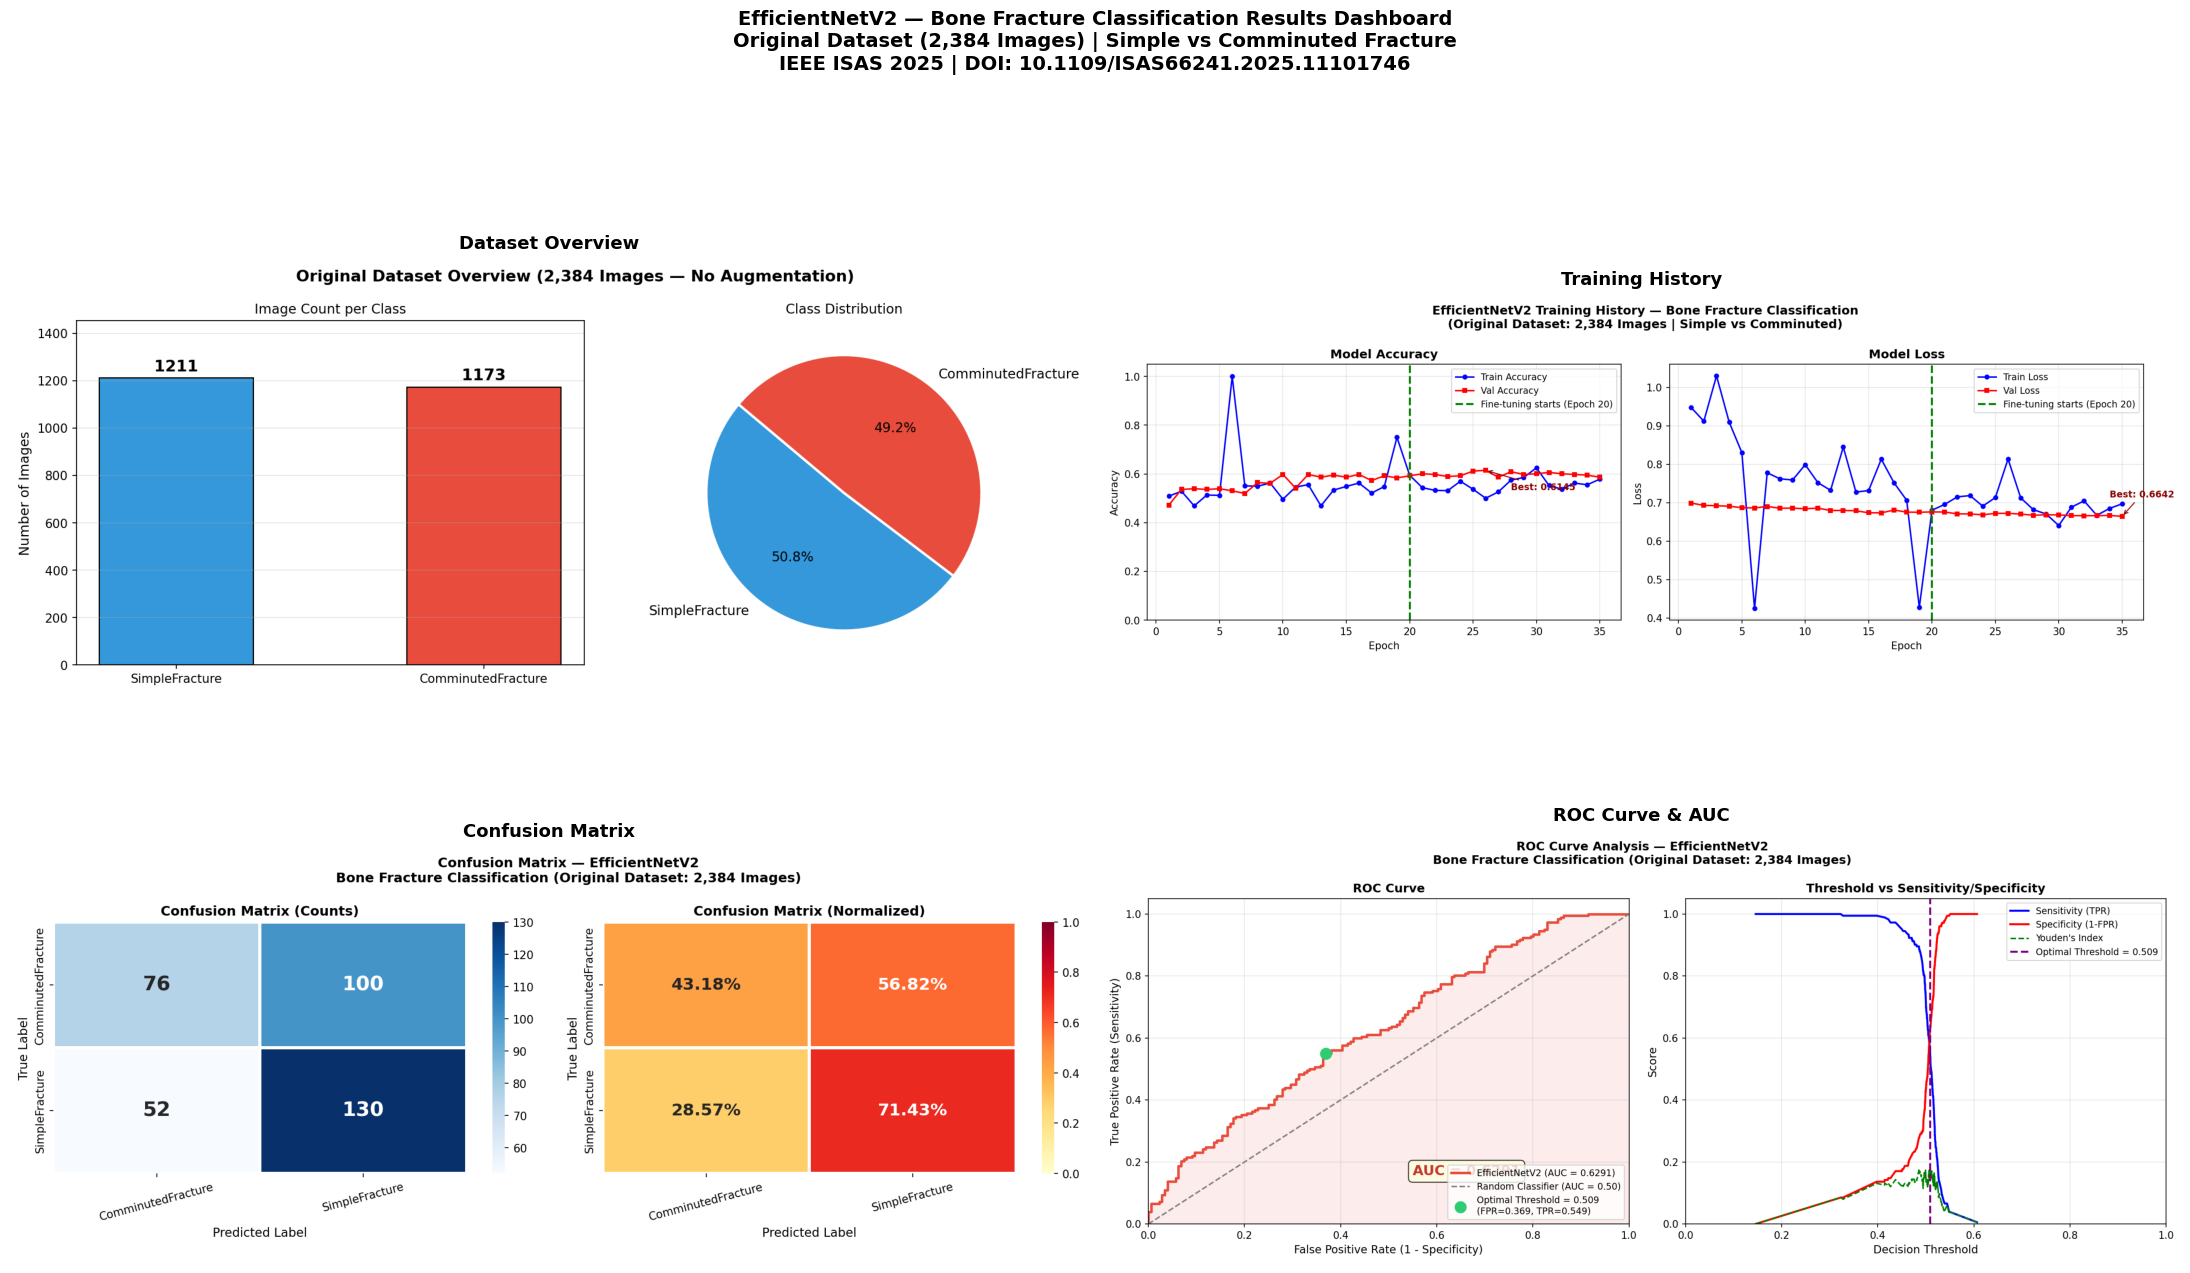

✅ Dashboard saved as '06_full_results_dashboard.png'


In [36]:
dashboard_files = [
    ('/content/drive/MyDrive/01_class_distribution.png', 'Dataset Overview'),
    ('/content/drive/MyDrive/03_training_curves.png',    'Training History'),
    ('/content/drive/MyDrive/04_confusion_matrix.png',   'Confusion Matrix'),
    ('/content/drive/MyDrive/05_roc_curve.png',          'ROC Curve & AUC'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle(
    'EfficientNetV2 — Bone Fracture Classification Results Dashboard\n'
    'Original Dataset (2,384 Images) | Simple vs Comminuted Fracture\n'
    'IEEE ISAS 2025 | DOI: 10.1109/ISAS66241.2025.11101746',
    fontsize=14, fontweight='bold', y=1.01
)

for ax, (fname, title) in zip(axes.flatten(), dashboard_files):
    if os.path.exists(fname):
        img = Image.open(fname)
        ax.imshow(np.array(img))
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    else:
        ax.text(0.5, 0.5, f'{fname}\n(Run previous cells first)',
                ha='center', va='center', fontsize=10, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/06_full_results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as '06_full_results_dashboard.png'")

## ✨ Final Evaluation Outcome Summary

This notebook successfully implemented and evaluated an EfficientNetV2 model with transfer learning for bone fracture classification. The model was trained on the original dataset of 2,384 images (Simple Fracture vs Comminuted Fracture), following a two-phase training approach (feature extraction and fine-tuning).

**Key Test Set Results (on unseen data):**

-   **Accuracy:** 57.54%
-   **AUC (ROC):** 0.6291
-   **Precision:** 0.5652
-   **Recall:** 0.7143
-   **F1-Score:** 0.6311
-   **Sensitivity:** 71.4% (ability to correctly identify Simple Fractures)
-   **Specificity:** 43.2% (ability to correctly identify Comminuted Fractures)

The model demonstrates a stronger recall for Simple Fractures but shows room for improvement in overall accuracy and specificity for Comminuted Fractures. The `06_full_results_dashboard.png` image (displayed above) provides a comprehensive visual summary of the training history, class distribution, confusion matrix, and ROC curve.

## 🦴 Simulation Complete!

| # | Step | What Was Done |
|---|------|---------------|
| 1 | Libraries | TensorFlow, Scikit-learn, Matplotlib imported |
| 2 | Config | Dataset paths, hyperparameters set |
| 3 | Exploration | 2,384 images verified, class distribution plotted |
| 4 | Visualization | Sample X-ray images displayed |
| 5 | Split | 70% Train \| 15% Val \| 15% Test |
| 6 | Preprocessing | Augmentation + normalization pipeline |
| 7 | Model Build | EfficientNetV2S + Transfer Learning head |
| 8 | Phase 1 Training | Classification head trained (backbone frozen) |
| 9 | Phase 2 Fine-Tuning | Last 10 backbone layers unfrozen |
| 10 | Training Curves | Accuracy & Loss plots |
| 11 | Test Evaluation | Test accuracy, AUC, precision, recall |
| 12 | Classification Report | Per-class metrics |
| 13 | Confusion Matrix | Counts + Normalized heatmap |
| 14 | ROC Curve | AUC score + threshold analysis |
| 15 | Final Summary | All metrics consolidated |
| 16 | Dashboard | All plots in one image |

---
*Capstone Project — MSc Data Science and Computational Techniques*  
*2nd Evaluation: Simulation Reproduction of IEEE ISAS 2025 Paper*